# 🛍️Shopping Mall Customer Analyzer
**Goal:** Understand customer behavior and segment them using K-Means clustering.

**Pipeline:** `Dataset → Cleaning → EDA → Visualization → ML Model → Insights`

---

In [ ]:
# Run this cell only if packages are not installed
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"], check=True)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("✅ Libraries loaded.")

✅ Libraries loaded.


## 1. 📦 Dataset
Using the Mall Customer Segmentation dataset (from Kaggle). Contains 200 customers with Age, Gender, Annual Income, and Spending Score.

In [2]:
try:
    # Load the dataset
    df = pd.read_csv("Mall_Customers.csv")
    print("✅ Dataset loaded successfully.")
except FileNotFoundError:
    # Fallback: generate representative synthetic data for demo
    np.random.seed(42)
    n = 200
    df = pd.DataFrame({
        'CustomerID': np.arange(1, n + 1),
        'Gender': np.random.choice(['Male', 'Female'], n, p=[0.44, 0.56]),
        'Age': np.concatenate([
            np.random.randint(18, 30, 50),
            np.random.randint(30, 45, 70),
            np.random.randint(45, 70, 80)
        ]),
        'Annual Income (k$)': np.concatenate([
            np.random.randint(15, 40, 60),
            np.random.randint(40, 75, 80),
            np.random.randint(75, 137, 60)
        ]),
        'Spending Score (1-100)': np.concatenate([
            np.random.randint(60, 100, 50),
            np.random.randint(30, 70, 80),
            np.random.randint(1, 45, 70)
        ])
    })
    print("ℹ️ Mall_Customers.csv not found — using synthetic demo data")
    print("   Download real dataset: https://www.kaggle.com/datasets/shwetabh123/mall-customers")

    df.head()

✅ Dataset loaded successfully.


## 🧹 2. Data Cleaning and Overview

In [3]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (200, 5)

Column names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
 CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicates: 0


In [4]:
# Standardize column names for easy access
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

# No missing values in this dataset — verify anyway
assert df.isnull().sum().sum() == 0, "Missing values found!"
assert df.duplicated().sum() == 0, "Duplicates found!"

print("✅ Data clean — ready for analysis")
df.describe().round(2)

✅ Data clean — ready for analysis


,CustomerID,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


## 🔍 3. Customer Analysis
Answering key business questions:
- Which age group spends most?
- Male vs female spending?
- High income but low spending customers?

In [5]:
# Q1: Which age group spends most?
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

age_spending = df.groupby('Age_Group', observed=True)['Spending_Score'].agg(['mean', 'count']).round(2)
age_spending.columns = ['Avg_Spending_Score', 'Customer_Count']
print("📊 Spending by Age Group:")
print(age_spending)
top_age = age_spending['Avg_Spending_Score'].idxmax()
print(f"\n🏆 Highest spending age group: {top_age}")

📊 Spending by Age Group:
           Avg_Spending_Score  Customer_Count
Age_Group                                    
18-25                   54.35              34
26-35                   64.45              60
36-45                   44.83              36
46-55                   36.70              37
56-70                   38.38              29

🏆 Highest spending age group: 26-35


In [6]:
# Q2: Male vs Female spending
gender_stats = df.groupby('Gender')[['Annual_Income', 'Spending_Score']].mean().round(2)
print("📊 Gender Comparison:")
print(gender_stats)

📊 Gender Comparison:
        Annual_Income  Spending_Score
Gender                               
Female          59.25           51.53
Male            62.23           48.51


In [7]:
# Q3: High income but low spending (potential target customers)
income_threshold = df['Annual_Income'].quantile(0.66)
spending_threshold = df['Spending_Score'].quantile(0.33)

high_income_low_spend = df[
    (df['Annual_Income'] >= income_threshold) &
    (df['Spending_Score'] <= spending_threshold)
]
print(f"💡 High Income (≥{income_threshold:.0f}k) + Low Spending (≤{spending_threshold:.0f}):")
print(f"   {len(high_income_low_spend)} customers — prime upsell targets")
print(f"   Avg income: {high_income_low_spend['Annual_Income'].mean():.1f}k")
print(f"   Avg spending score: {high_income_low_spend['Spending_Score'].mean():.1f}")

💡 High Income (≥71k) + Low Spending (≤41):
   34 customers — prime upsell targets
   Avg income: 88.9k
   Avg spending score: 18.4


## 4. 📊 Data Visualization

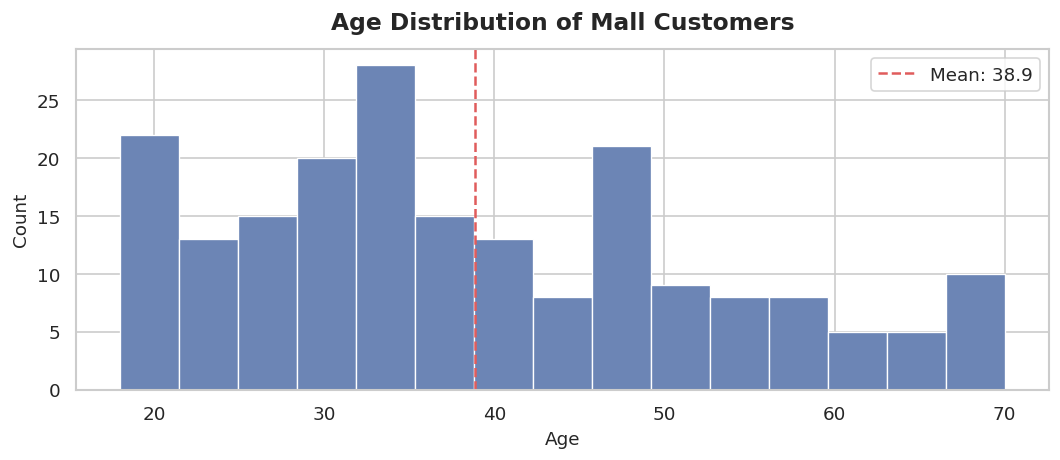

✅ Plot 1: Age Distribution


In [8]:
# Plot 1: Age Distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Age'], bins=15, color='#6C85B5', edgecolor='white', linewidth=0.8)
ax.set_title('Age Distribution of Mall Customers', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.axvline(df['Age'].mean(), color='#E05C5C', linestyle='--', linewidth=1.5, label=f"Mean: {df['Age'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig('plot1_age_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Plot 1: Age Distribution")

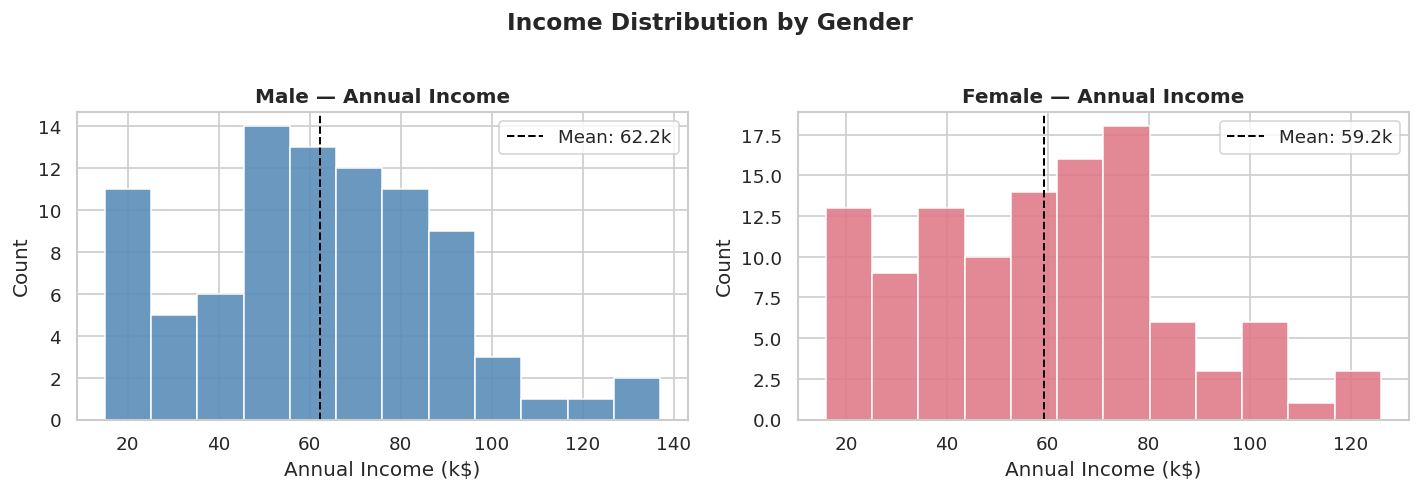

✅ Plot 2: Income Distribution


In [9]:
# Plot 2: Income Distribution by Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, gender, color in zip(axes, ['Male', 'Female'], ['#5B8DB8', '#E07B8A']):
    data = df[df['Gender'] == gender]['Annual_Income']
    ax.hist(data, bins=12, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(f'{gender} — Annual Income', fontsize=12, fontweight='bold')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.1f}k')
    ax.legend()

plt.suptitle('Income Distribution by Gender', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot2_income_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Plot 2: Income Distribution")

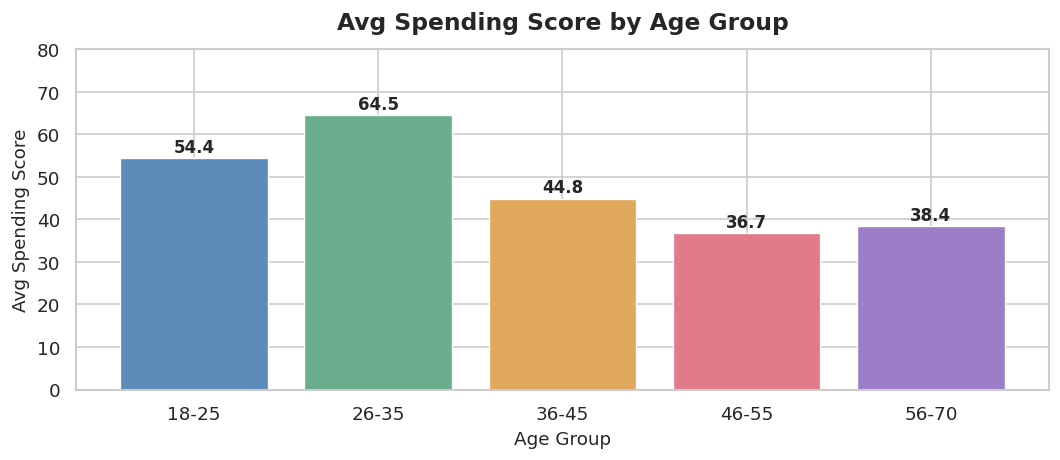

✅ Plot 3: Spending by Age Group


In [10]:
# Plot 3: Spending Score by Age Group
fig, ax = plt.subplots(figsize=(9, 4))
age_colors = ['#5B8DB8', '#6BAE8E', '#E0A85C', '#E07B8A', '#9B7DC8']
age_means = df.groupby('Age_Group', observed=True)['Spending_Score'].mean()
bars = ax.bar(age_means.index.astype(str), age_means.values, color=age_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, age_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Avg Spending Score by Age Group', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Avg Spending Score', fontsize=11)
ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig('plot3_spending_by_age.png', bbox_inches='tight')
plt.show()
print("✅ Plot 3: Spending by Age Group")

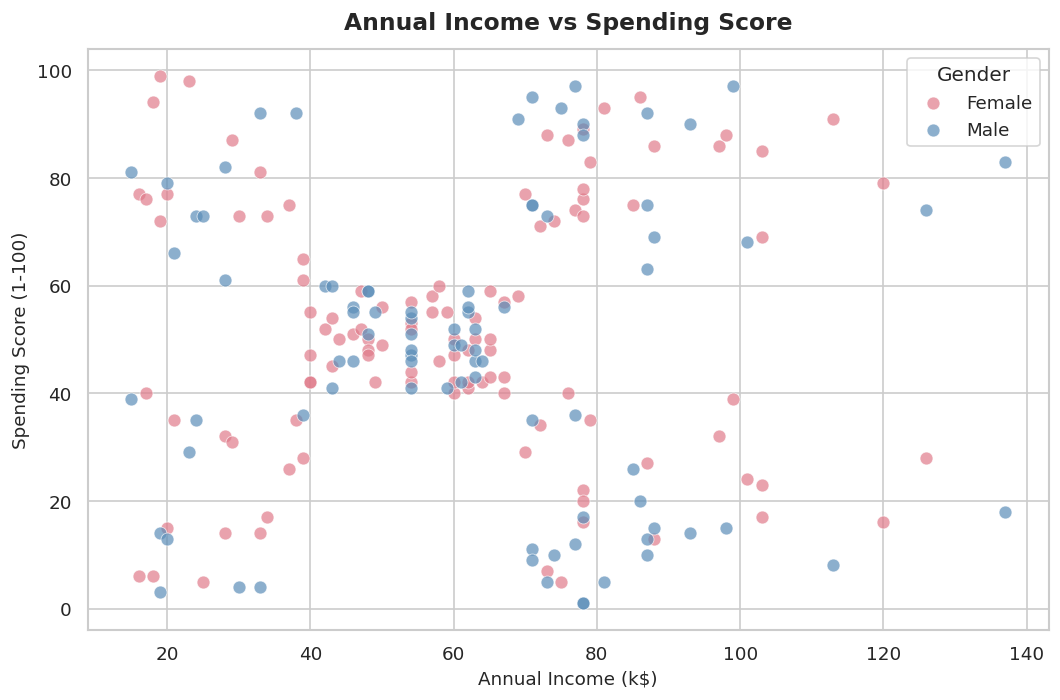

✅ Plot 4: Income vs Spending Scatter


In [11]:
# Plot 4: Income vs Spending Scatter
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'Male': '#5B8DB8', 'Female': '#E07B8A'}
for gender, group in df.groupby('Gender'):
    ax.scatter(group['Annual_Income'], group['Spending_Score'],
               c=colors[gender], label=gender, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

ax.set_title('Annual Income vs Spending Score', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Annual Income (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1-100)', fontsize=11)
ax.legend(title='Gender')
plt.tight_layout()
plt.savefig('plot4_income_vs_spending.png', bbox_inches='tight')
plt.show()
print("✅ Plot 4: Income vs Spending Scatter")

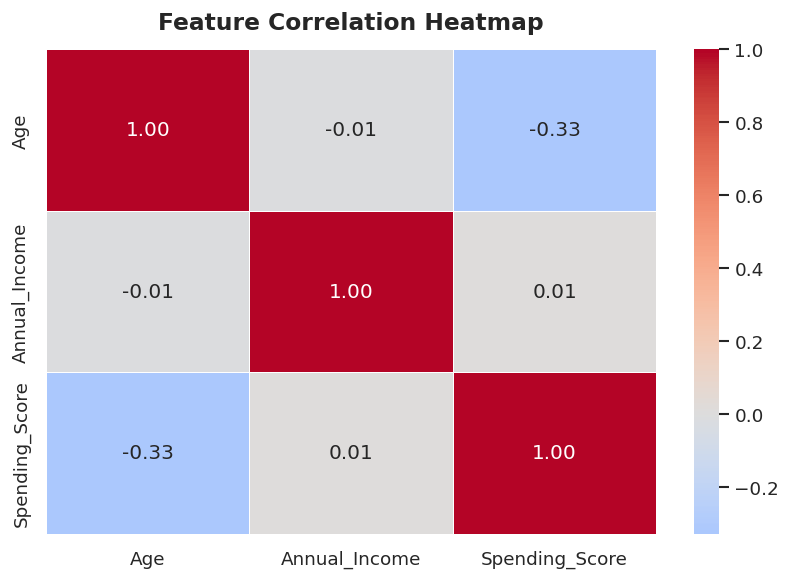

✅ Plot 5: Correlation Heatmap


In [12]:
# Plot 5: Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['Age', 'Annual_Income', 'Spending_Score']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 12})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Plot 5: Correlation Heatmap")

## 🤖 5. K-Means Customer Segmentation

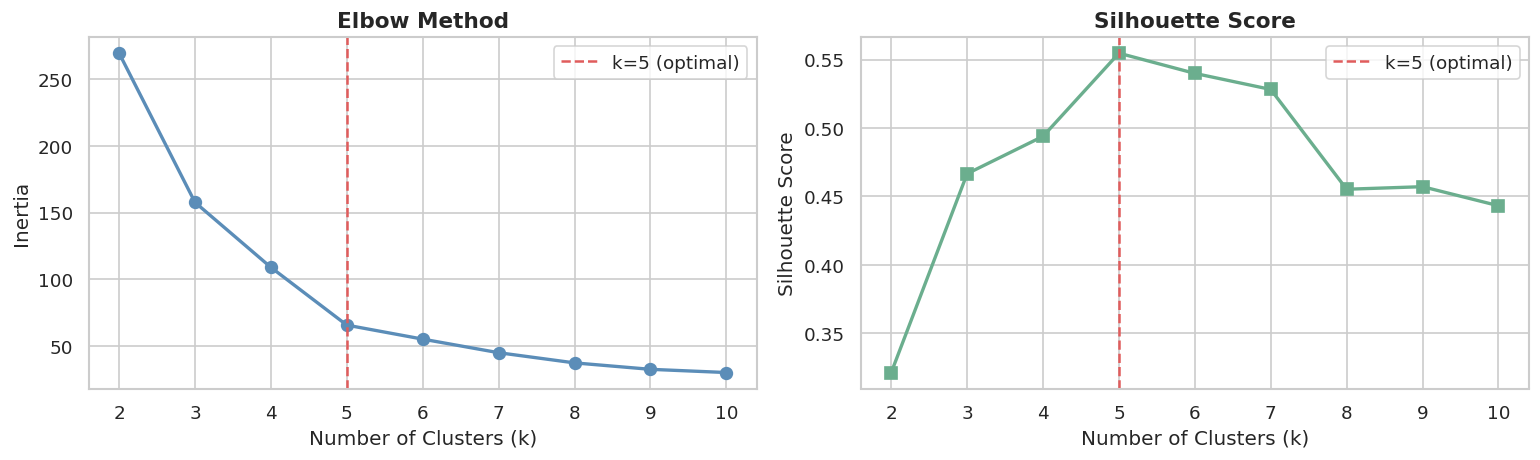

✅ Optimal k=5 | Best Silhouette: 0.555 at k=5


In [13]:
# Feature selection for clustering
X = df[['Annual_Income', 'Spending_Score']].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to find optimal clusters
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow and Silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertia, 'o-', color='#5B8DB8', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(5, color='#E05C5C', linestyle='--', linewidth=1.5, label='k=5 (optimal)')
axes[0].legend()

axes[1].plot(K_range, silhouette, 's-', color='#6BAE8E', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(5, color='#E05C5C', linestyle='--', linewidth=1.5, label='k=5 (optimal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot6_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f"✅ Optimal k=5 | Best Silhouette: {max(silhouette):.3f} at k={list(K_range)[silhouette.index(max(silhouette))]}")

In [14]:
# Train final model with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Centers (Income, Spending):")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: Income={c[0]:.1f}k  Spending={c[1]:.1f}")

Cluster Centers (Income, Spending):
  Cluster 0: Income=55.3k  Spending=49.5
  Cluster 1: Income=86.5k  Spending=82.1
  Cluster 2: Income=25.7k  Spending=79.4
  Cluster 3: Income=88.2k  Spending=17.1
  Cluster 4: Income=26.3k  Spending=20.9


In [15]:
# Label clusters based on income-spending quadrants
cluster_stats = df.groupby('Cluster')[['Annual_Income', 'Spending_Score']].mean()

def label_cluster(row):
    inc, spend = row['Annual_Income'], row['Spending_Score']
    if inc >= 60 and spend >= 60:
        return 'Premium Shoppers'
    elif inc <= 45 and spend >= 60:
        return 'Budget High Spenders'
    elif inc >= 60 and spend <= 45:
        return 'High Income Low Spend'
    elif inc <= 45 and spend <= 45:
        return 'Low Spenders'
    else:
        return 'Average Shoppers'

cluster_labels = cluster_stats.apply(label_cluster, axis=1)
df['Segment'] = df['Cluster'].map(cluster_labels)

print("Cluster → Segment Mapping:")
print(cluster_labels.to_string())

Cluster → Segment Mapping:
Cluster
0         Average Shoppers
1         Premium Shoppers
2     Budget High Spenders
3    High Income Low Spend
4             Low Spenders


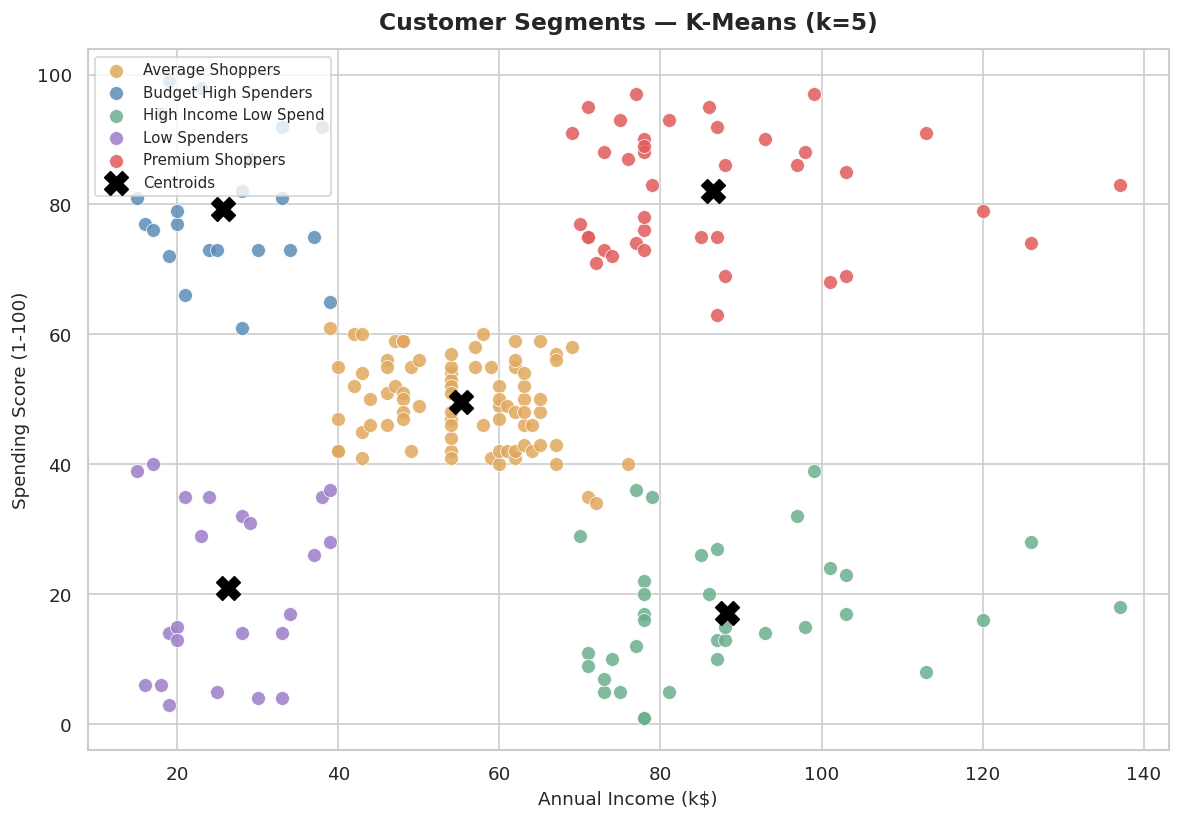

✅ Plot 7: Customer Segments


In [16]:
# Final cluster visualization
SEGMENT_COLORS = {
    'Premium Shoppers':       '#E05C5C',
    'Budget High Spenders':   '#5B8DB8',
    'High Income Low Spend':  '#6BAE8E',
    'Low Spenders':           '#9B7DC8',
    'Average Shoppers':       '#E0A85C'
}

fig, ax = plt.subplots(figsize=(10, 7))
for segment, group in df.groupby('Segment'):
    ax.scatter(group['Annual_Income'], group['Spending_Score'],
               c=SEGMENT_COLORS[segment], label=segment, s=70,
               alpha=0.85, edgecolors='white', linewidth=0.5)

# Plot centroids
ax.scatter(centers[:, 0], centers[:, 1], s=200, c='black',
           marker='X', zorder=5, label='Centroids')

ax.set_title('Customer Segments — K-Means (k=5)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Annual Income (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1-100)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('plot7_customer_segments.png', bbox_inches='tight')
plt.show()
print("✅ Plot 7: Customer Segments")

## 💡 6. Business Insights

In [17]:
# Segment summary table
summary = df.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Female_Pct=('Gender', lambda x: (x == 'Female').mean() * 100)
).round(1)

print("=" * 70)
print("CUSTOMER SEGMENT SUMMARY")
print("=" * 70)
print(summary.to_string())
print("=" * 70)

CUSTOMER SEGMENT SUMMARY
                       Customer_Count  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
Segment                                                                             
Average Shoppers                   81     42.7        55.3          49.5        59.3
Budget High Spenders               22     25.3        25.7          79.4        59.1
High Income Low Spend              35     41.1        88.2          17.1        45.7
Low Spenders                       23     45.2        26.3          20.9        60.9
Premium Shoppers                   39     32.7        86.5          82.1        53.8


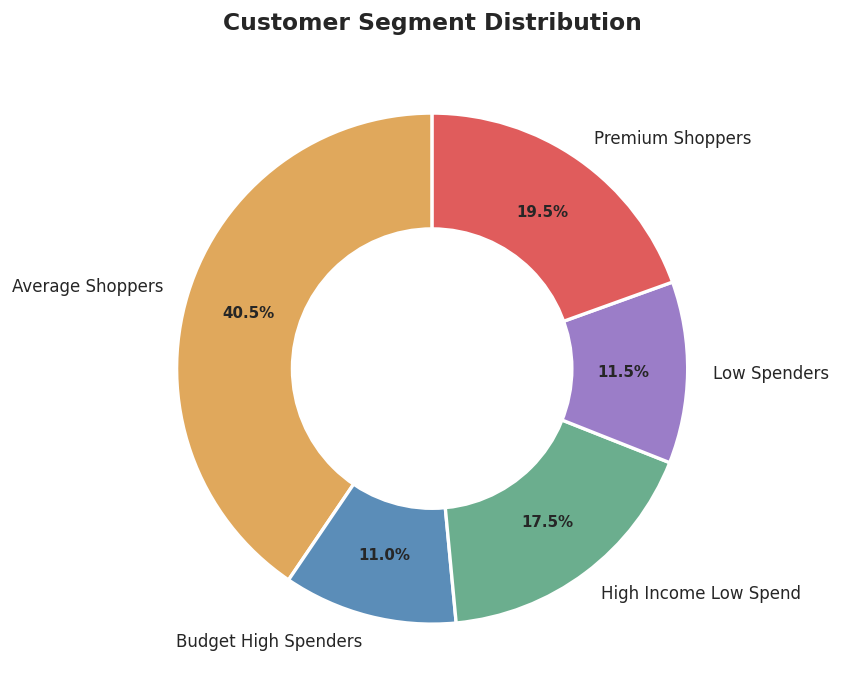

✅ Plot 8: Segment Distribution


In [18]:
# Segment size donut chart
fig, ax = plt.subplots(figsize=(8, 6))
sizes = summary['Customer_Count']
colors = [SEGMENT_COLORS[s] for s in sizes.index]
wedges, texts, autotexts = ax.pie(
    sizes, labels=sizes.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

# Donut hole
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot8_segment_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Plot 8: Segment Distribution")

## 📋 7. Key Insights & Recommendations

| Segment | Business Action |
|---|---|
| **Premium Shoppers** | Loyalty programs, exclusive offers |
| **High Income Low Spend** | Targeted campaigns to convert — highest revenue potential |
| **Budget High Spenders** | Affordable bundles, frequent promotions |
| **Average Shoppers** | Upsell with personalized recommendations |
| **Low Spenders** | Re-engagement campaigns or deprioritize marketing spend |

**Summary findings:**
- Age group 18–35 has highest spending scores
- High Income Low Spenders = biggest untapped revenue opportunity
- Female customers have slightly higher spending scores on average
- K-Means successfully identifies 5 distinct, actionable customer personas

---
*Built for GSSoC | Dataset: Mall Customer Segmentation | Model: K-Means Clustering (k=5)*